# Ajuste Fino e Visualização de Filtros (PDI)

Este notebook permite executar o pipeline de segmentação passo a passo, mostrando os resultados intermediários gerados a cada filtro aplicado. Altere as variáveis na primeira célula de código para ajustar os pesos e limiares das operações.

In [25]:
# =========================================================================
# PARÂMETROS E PESOS DAS OPERAÇÕES (AJUSTE AQUI)
# =========================================================================

# 1. ROI Horizontal
ROI_X_MIN = 250
ROI_X_MAX = 1030

# 2. Binarização Dinâmica (Tentativa Inicial)
BIN_PERCENTILE = 90  # Percentil inicial para limiar adaptativo (com fallback para 85, 80)

# 3. Operação Morfológica (Fechamento)
MORPH_KERNEL_W = 15
MORPH_KERNEL_H = 15

# 4. Filtragem de Contornos por Tamanho/Área
MIN_WIDTH = 60
MIN_HEIGHT = 60
MAX_WIDTH = 350
MAX_HEIGHT = 350
MIN_AREA = 4000

# 5. Margem de Segurança (Padding)
PADDING = 20


Imagem carregada com sucesso! Resolução: 1280x720


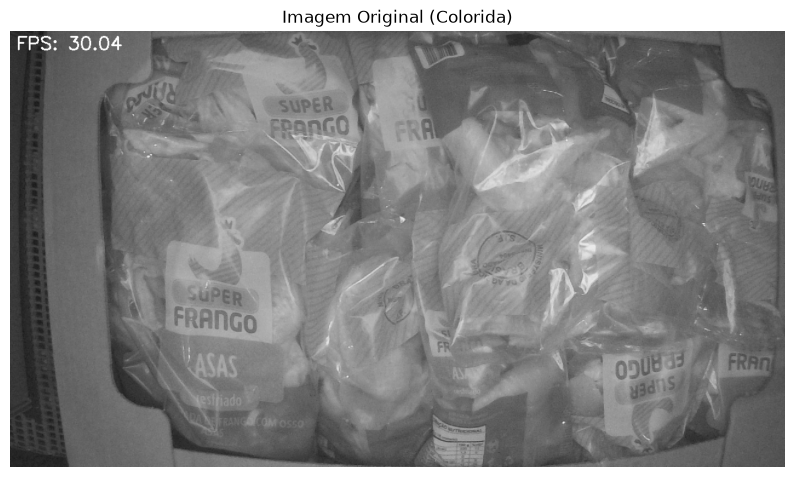

In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Caminho de uma imagem de teste
img_path = "Train_and_Validation/93000003_Asas_Resfriado_Selado/TesteTempoPosicao2025-02-05 14_14_11.524118.jpg"

# Carrega as imagens
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_color = cv2.imread(img_path, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

if img_gray is None:
    print(f"Erro: Não foi possível carregar a imagem em {img_path}")
else:
    print(f"Imagem carregada com sucesso! Resolução: {img_gray.shape[1]}x{img_gray.shape[0]}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title("Imagem Original (Colorida)")
    plt.axis("off")
    plt.show()

### Etapa 1: Região de Interesse (ROI) Horizontal
Removemos as laterais da imagem (onde ficam a esteira transportadora e as abas da caixa) aplicando a máscara.

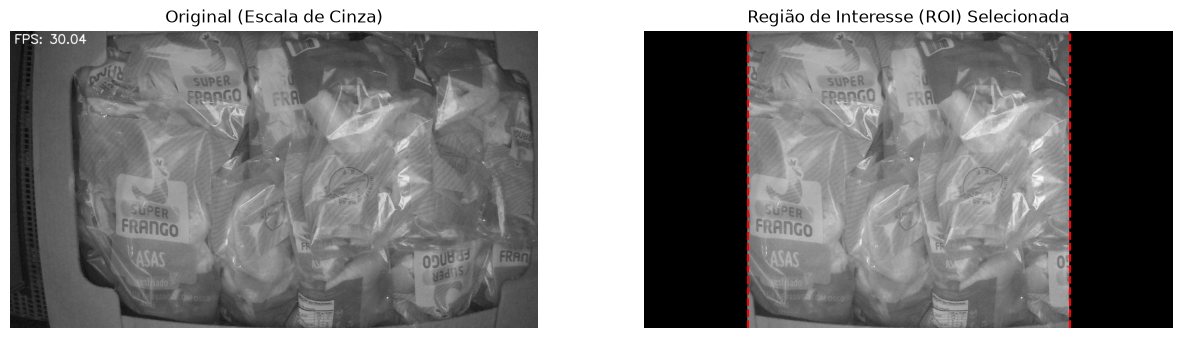

In [27]:
mask = np.zeros_like(img_gray)
mask[:, ROI_X_MIN:ROI_X_MAX] = 255
masked_img = cv2.bitwise_and(img_gray, mask)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Original (Escala de Cinza)")
axes[0].axis("off")

axes[1].imshow(masked_img, cmap='gray')
axes[1].axvline(ROI_X_MIN, color='red', linestyle='--')
axes[1].axvline(ROI_X_MAX, color='red', linestyle='--')
axes[1].set_title("Região de Interesse (ROI) Selecionada")
axes[1].axis("off")

plt.show()

### Etapa 2: Binarização Dinâmica por Percentil
Calcula o limiar baseado no percentil dos pixels dentro da ROI.

Limiar dinâmico calculado (Percentil 90): 165.00


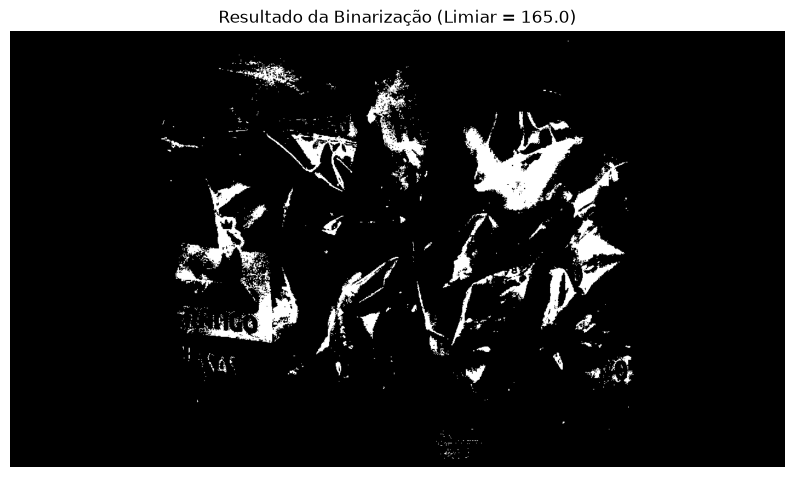

In [28]:
# Binarização com lógica de fallback
pixels_inside = img_gray[:, ROI_X_MIN:ROI_X_MAX].flatten()

thresh = None
thresh_val = 0
# Tentamos percentis de 90 a 80 até encontrar algum contorno válido na etapa de fechamento
for p in [90, 85, 80]:
    thresh_val = np.percentile(pixels_inside, p)
    _, t = cv2.threshold(masked_img, thresh_val, 255, cv2.THRESH_BINARY)
    
    # Faz uma checagem rápida de fechamento para ver se gera candidatos
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (MORPH_KERNEL_W, MORPH_KERNEL_H))
    c = cv2.morphologyEx(t, cv2.MORPH_CLOSE, k)
    cnts, _ = cv2.findContours(c, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    has_geom_cands = False
    for cnt in cnts:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        cx = x + w/2.0
        if w >= MIN_WIDTH and h >= MIN_HEIGHT and area >= MIN_AREA and w < MAX_WIDTH and h < MAX_HEIGHT:
            if ROI_X_MIN < cx < ROI_X_MAX:
                has_geom_cands = True
                break
    
    if has_geom_cands:
        thresh = t
        BIN_PERCENTILE = p
        break

if thresh is None:
    # Se nenhum gerou candidatos normais, tenta busca relaxada
    for p in [90, 85, 80]:
        thresh_val = np.percentile(pixels_inside, p)
        _, t = cv2.threshold(masked_img, thresh_val, 255, cv2.THRESH_BINARY)
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        c = cv2.morphologyEx(t, cv2.MORPH_CLOSE, k)
        cnts, _ = cv2.findContours(c, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        has_geom_cands = False
        for cnt in cnts:
            x, y, w, h = cv2.boundingRect(cnt)
            area = w * h
            cx = x + w/2.0
            if w >= 40 and h >= 40 and area >= 1600 and w < 400 and h < 400:
                if ROI_X_MIN < cx < ROI_X_MAX:
                    has_geom_cands = True
                    break
        if has_geom_cands:
            thresh = t
            BIN_PERCENTILE = p
            break
            
if thresh is None:
    thresh_val = np.percentile(pixels_inside, BIN_PERCENTILE)
    _, thresh = cv2.threshold(masked_img, thresh_val, 255, cv2.THRESH_BINARY)

print(f"Limiar dinâmico calculado (Percentil {BIN_PERCENTILE}): {thresh_val:.2f}")

plt.figure(figsize=(10, 6))
plt.imshow(thresh, cmap='gray')
plt.title(f"Resultado da Binarização (Limiar = {thresh_val:.1f})")
plt.axis("off")
plt.show()


### Etapa 3: Operação Morfológica (Fechamento)
Aplica o fechamento morfológico para fundir o texto e preencher buracos pretos do rótulo.

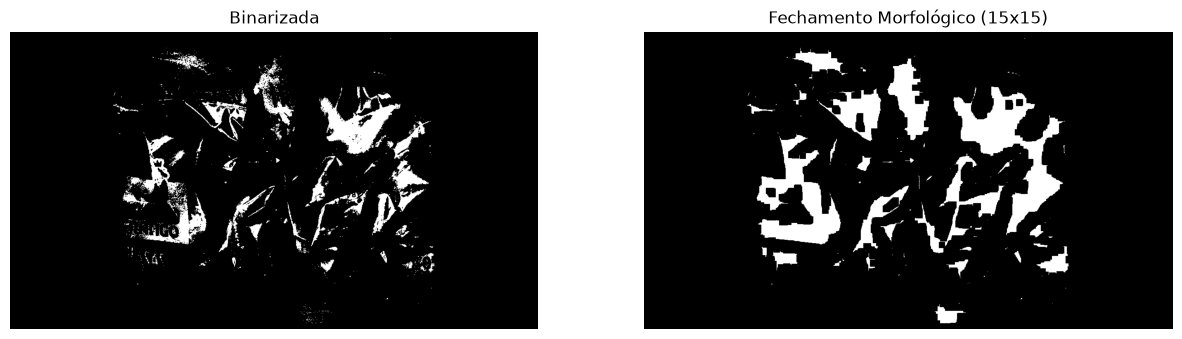

In [29]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (MORPH_KERNEL_W, MORPH_KERNEL_H))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(thresh, cmap='gray')
axes[0].set_title("Binarizada")
axes[0].axis("off")

axes[1].imshow(closed, cmap='gray')
axes[1].set_title(f"Fechamento Morfológico ({MORPH_KERNEL_W}x{MORPH_KERNEL_H})")
axes[1].axis("off")

plt.show()


### Etapa 4: Extração e Filtragem Geométrica de Contornos
Detecta e filtra os contornos com base nos limites de tamanho, área e posição horizontal.

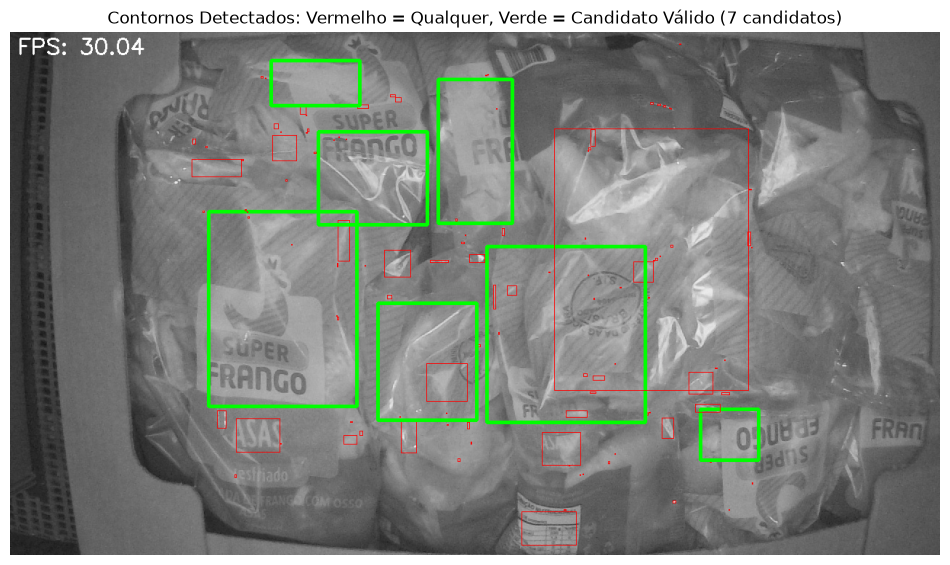

In [30]:
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contours = img_rgb.copy()

candidates = []
for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    area = w * h
    cx = x + w/2.0

    # Desenha todos os contornos detectados em vermelho bem fino
    cv2.rectangle(img_contours, (x, y), (x+w, y+h), (255, 0, 0), 1)

    # Aplica os filtros geométricos (tenta filtros normais, senão relaxados)
    if w >= 60 and h >= 60 and area >= 4000 and w < 350 and h < 350:
        if ROI_X_MIN < cx < ROI_X_MAX:
            candidates.append((x, y, w, h, area))
            cv2.rectangle(img_contours, (x, y), (x+w, y+h), (0, 255, 0), 3)

if not candidates:
    # Fallback relaxado para visualização no contorno do notebook se necessário
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = w * h
        cx = x + w/2.0
        if w >= 40 and h >= 40 and area >= 1600 and w < 400 and h < 400:
            if ROI_X_MIN < cx < ROI_X_MAX:
                candidates.append((x, y, w, h, area))
                cv2.rectangle(img_contours, (x, y), (x+w, y+h), (0, 255, 0), 3)

plt.figure(figsize=(12, 8))
plt.imshow(img_contours)
plt.title(f"Contornos Detectados: Vermelho = Qualquer, Verde = Candidato Válido ({len(candidates)} candidatos)")
plt.axis("off")
plt.show()


### Etapa 5: Filtro de Rótulo Real (Textura, Contraste e Recortes)
Analisa o desvio padrão de cores, canny edge ratio e pixels escuros para validar se realmente é o rótulo antes de fazer o crop.

Ranking dos candidatos encontrados:
Rank 1: Box=(x=424, y=137, w=150, h=128)
  - Score: 5.4e+12
  - Mínimo: 54 (Inconsistência de tinta/barras)
  - Média: 146.2 (Brilho do papel)
  - Desvio Padrão: 24.0
  - Variância Laplaciana: 400.9 (Nível de detalhes/texto)
  - Aspect Ratio: 1.17
  - Área: 19200
--------------------------------------------------
Rank 2: Box=(x=656, y=295, w=218, h=242)
  - Score: 3.2e+12
  - Mínimo: 85 (Inconsistência de tinta/barras)
  - Média: 143.1 (Brilho do papel)
  - Desvio Padrão: 16.5
  - Variância Laplaciana: 152.1 (Nível de detalhes/texto)
  - Aspect Ratio: 0.90
  - Área: 52756
--------------------------------------------------
Rank 3: Box=(x=273, y=247, w=204, h=268)
  - Score: 3.1e+12
  - Mínimo: 89 (Inconsistência de tinta/barras)
  - Média: 148.9 (Brilho do papel)
  - Desvio Padrão: 17.6
  - Variância Laplaciana: 131.4 (Nível de detalhes/texto)
  - Aspect Ratio: 0.76
  - Área: 54672
--------------------------------------------------
Rank 4: Box=(x=506,

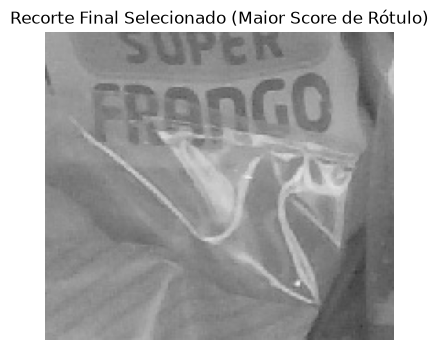

In [31]:
valid_crops = []
scored_candidates = []

for idx, (x, y, w, h, area) in enumerate(candidates):
    crop_gray = img_gray[y:y+h, x:x+w]
    min_val = crop_gray.min()
    std_val = crop_gray.std()
    mean_val = crop_gray.mean()
    lap_var = cv2.Laplacian(crop_gray, cv2.CV_64F).var()

    aspect = w / float(h)
    if aspect < 0.5 or aspect > 2.5:
        aspect_penalty = 0.01
    else:
        aspect_penalty = 1.0

    # Formula de Score do Rótulo Real (inclui área para priorizar o rótulo principal sobre pequenas rugas/brilhos)
    score = area * mean_val * lap_var * std_val * (255.0 - min_val) * aspect_penalty

    scored_candidates.append({
        'box': (x, y, w, h),
        'score': score,
        'min': min_val,
        'std': std_val,
        'mean': mean_val,
        'lap': lap_var,
        'aspect': aspect,
        'area': area
    })

# Ordena e seleciona o melhor candidato
if scored_candidates:
    scored_candidates.sort(key=lambda x: x['score'], reverse=True)
    
    print("Ranking dos candidatos encontrados:")
    for rank, cand in enumerate(scored_candidates):
        x, y, w, h = cand['box']
        print(f"Rank {rank+1}: Box=(x={x}, y={y}, w={w}, h={h})")
        print(f"  - Score: {cand['score']:.1e}")
        print(f"  - Mínimo: {cand['min']} (Inconsistência de tinta/barras)")
        print(f"  - Média: {cand['mean']:.1f} (Brilho do papel)")
        print(f"  - Desvio Padrão: {cand['std']:.1f}")
        print(f"  - Variância Laplaciana: {cand['lap']:.1f} (Nível de detalhes/texto)")
        print(f"  - Aspect Ratio: {cand['aspect']:.2f}")
        print(f"  - Área: {cand['area']}")
        print("-" * 50)
        
    # Adiciona apenas o melhor candidato no valid_crops
    best = scored_candidates[0]
    bx, by, bw, bh = best['box']
    
    y1 = max(0, by - PADDING)
    y2 = min(img_rgb.shape[0], by + bh + PADDING)
    x1 = max(0, bx - PADDING)
    x2 = min(img_rgb.shape[1], bx + bw + PADDING)
    
    valid_crops.append(img_rgb[y1:y2, x1:x2])
else:
    print("Nenhum candidato encontrado.")

if len(valid_crops) > 0:
    plt.figure(figsize=(6, 4))
    plt.imshow(valid_crops[0])
    plt.title("Recorte Final Selecionado (Maior Score de Rótulo)")
    plt.axis("off")
    plt.show()
else:
    print("Nenhum rótulo válido encontrado.")


### Painel Consolidado de Comparação
Mostra a evolução de todas as etapas juntas em um único painel para facilitar a sintonia.

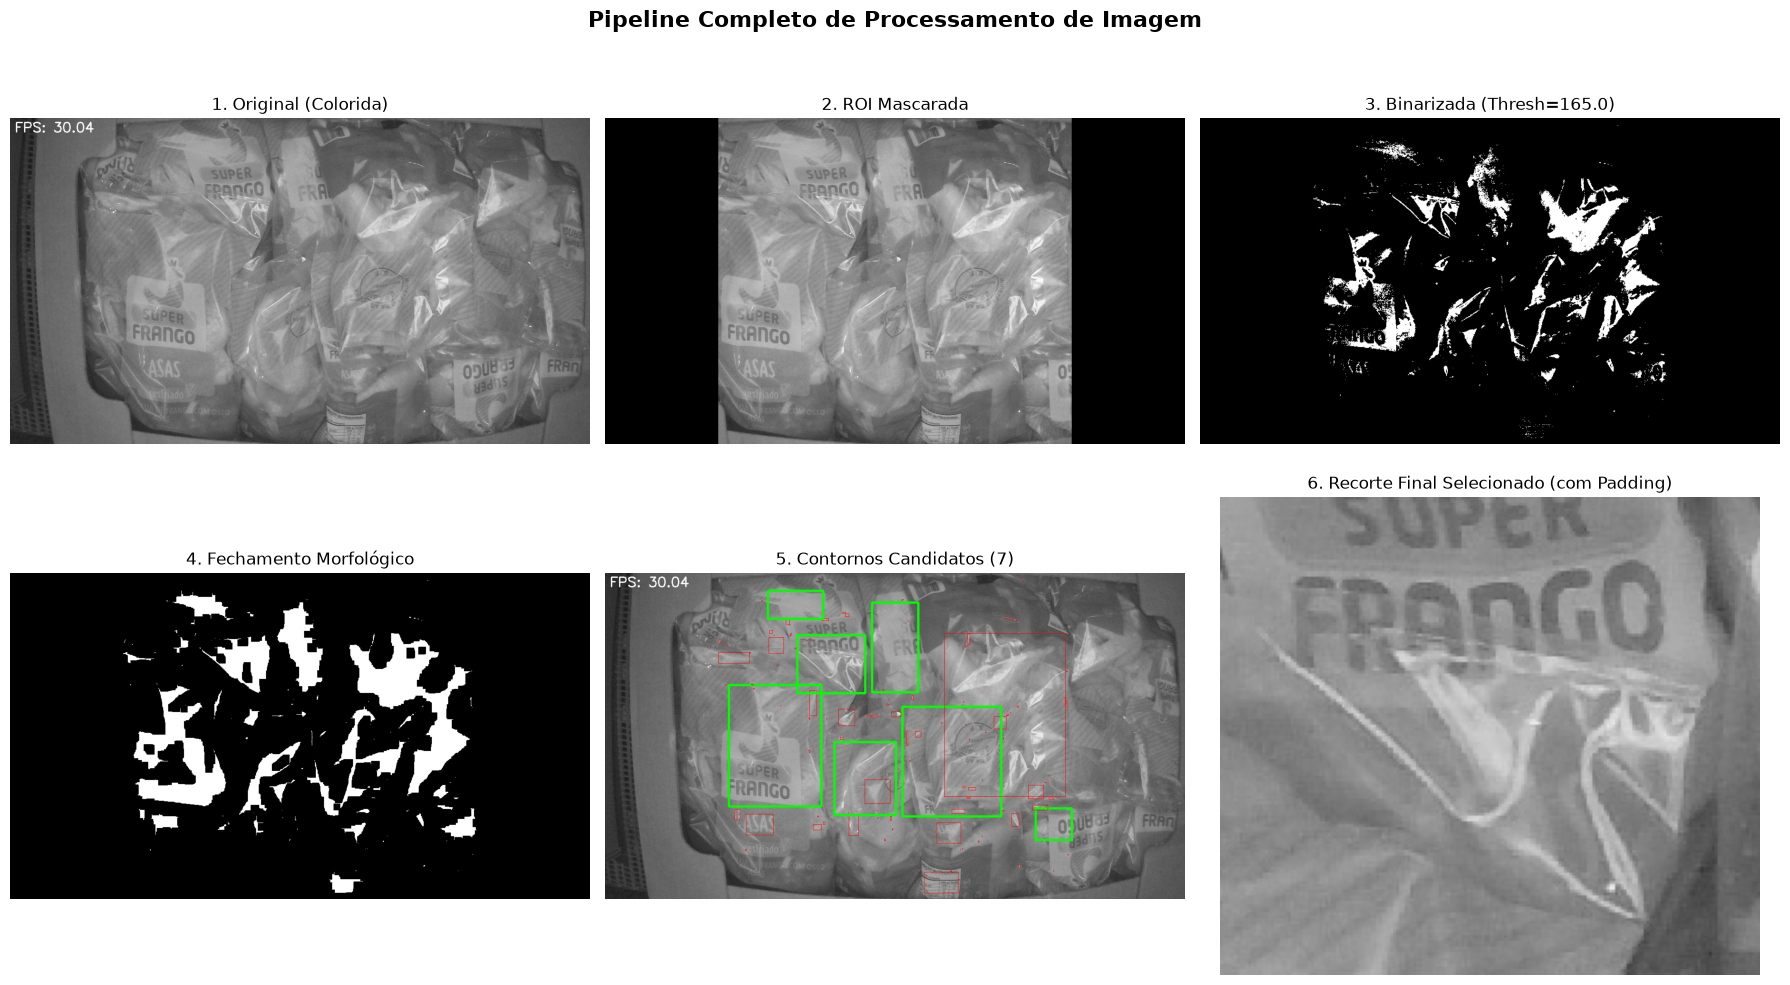

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. Original (Colorida)")
axes[0, 0].axis("off")

axes[0, 1].imshow(masked_img, cmap='gray')
axes[0, 1].set_title("2. ROI Mascarada")
axes[0, 1].axis("off")

axes[0, 2].imshow(thresh, cmap='gray')
axes[0, 2].set_title(f"3. Binarizada (Thresh={thresh_val:.1f})")
axes[0, 2].axis("off")

axes[1, 0].imshow(closed, cmap='gray')
axes[1, 0].set_title("4. Fechamento Morfológico")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_contours)
axes[1, 1].set_title(f"5. Contornos Candidatos ({len(candidates)})")
axes[1, 1].axis("off")

if len(valid_crops) > 0:
    axes[1, 2].imshow(valid_crops[0])
    axes[1, 2].set_title("6. Recorte Final Selecionado (com Padding)")
else:
    axes[1, 2].text(0.5, 0.5, 'Nenhum recorte gerado', ha='center', va='center', fontsize=12)
    axes[1, 2].set_title("6. Recorte Final")
axes[1, 2].axis("off")

plt.suptitle("Pipeline Completo de Processamento de Imagem", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### Execução em Lote (Processamento de Todo o Dataset)
A célula abaixo define o processamento completo de todas as classes e imagens contidas no diretório `Train_and_Validation`, gerando exatamente 1 recorte por imagem no diretório `resultado`.

In [33]:
# =========================================================================
# PROCESSAMENTO DO DATASET COMPLETO (RODAR PARA GERAR OS RECOTES DE SAÍDA)
# =========================================================================

def segment_image_dataset(img_path, output_dir, img_name):
    # Carrega a imagem original em escala de cinza para detecção
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Erro ao carregar a imagem: {img_path}")
        return 0

    img_color = cv2.imread(img_path, cv2.IMREAD_COLOR)

    mask = np.zeros_like(img)
    mask[:, ROI_X_MIN:ROI_X_MAX] = 255
    masked_img = cv2.bitwise_and(img, mask)

    pixels_inside = img[:, ROI_X_MIN:ROI_X_MAX].flatten()
    if len(pixels_inside) == 0:
        return 0

    candidates = []

    # 1. Limiarização Dinâmica com Fallback
    for p in [90, 85, 80]:
        thresh_val = np.percentile(pixels_inside, p)
        _, thresh = cv2.threshold(masked_img, thresh_val, 255, cv2.THRESH_BINARY)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (MORPH_KERNEL_W, MORPH_KERNEL_H))
        closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for c in contours:
            x, y, w, h = cv2.boundingRect(c)
            area = w * h
            cx = x + w/2

            if w >= MIN_WIDTH and h >= MIN_HEIGHT and area >= MIN_AREA and w < MAX_WIDTH and h < MAX_HEIGHT:
                if ROI_X_MIN < cx < ROI_X_MAX:
                    crop_gray = img[y:y+h, x:x+w]
                    
                    min_val = crop_gray.min()
                    std_val = crop_gray.std()
                    mean_val = crop_gray.mean()
                    lap_var = cv2.Laplacian(crop_gray, cv2.CV_64F).var()

                    aspect = w / float(h)
                    if aspect < 0.5 or aspect > 2.5:
                        aspect_penalty = 0.01
                    else:
                        aspect_penalty = 1.0

                    score = area * mean_val * lap_var * std_val * (255.0 - min_val) * aspect_penalty

                    candidates.append({
                        'box': (x, y, w, h),
                        'score': score
                    })

        if len(candidates) > 0:
            break

    # Fallback relaxado
    if len(candidates) == 0:
        for p in [90, 85, 80]:
            thresh_val = np.percentile(pixels_inside, p)
            _, thresh = cv2.threshold(masked_img, thresh_val, 255, cv2.THRESH_BINARY)
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
            closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
            contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            for c in contours:
                x, y, w, h = cv2.boundingRect(c)
                area = w * h
                cx = x + w/2
                if w >= 40 and h >= 40 and area >= 1600 and w < 400 and h < 400:
                    if ROI_X_MIN < cx < ROI_X_MAX:
                        crop_gray = img[y:y+h, x:x+w]
                        min_val = crop_gray.min()
                        std_val = crop_gray.std()
                        mean_val = crop_gray.mean()
                        lap_var = cv2.Laplacian(crop_gray, cv2.CV_64F).var()

                        aspect = w / float(h)
                        if aspect < 0.5 or aspect > 2.5:
                            aspect_penalty = 0.01
                        else:
                            aspect_penalty = 1.0

                        score = area * mean_val * lap_var * std_val * (255.0 - min_val) * aspect_penalty

                        candidates.append({
                            'box': (x, y, w, h),
                            'score': score
                        })
            if len(candidates) > 0:
                break

    if len(candidates) == 0:
        return 0

    best_cand = max(candidates, key=lambda x: x['score'])
    x, y, w, h = best_cand['box']

    y1 = max(0, y - PADDING)
    y2 = min(img.shape[0], y + h + PADDING)
    x1 = max(0, x - PADDING)
    x2 = min(img.shape[1], x + w + PADDING)

    crop_to_save = img_color[y1:y2, x1:x2] if img_color is not None else img[y1:y2, x1:x2]

    base_name, _ = os.path.splitext(img_name)
    out_name = f"{base_name}_segmentada_1.png"
    out_name = out_name.replace(":", "_")
    out_path = os.path.join(output_dir, out_name)
    cv2.imwrite(out_path, crop_to_save)

    return 1

def process_dataset(input_dir, output_dir):
    if not os.path.exists(input_dir):
        print(f"Diretório de entrada não encontrado: {input_dir}")
        return

    subdirs = sorted([d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))])
    total_images = 0
    total_crops = 0

    for subdir in subdirs:
        class_in_path = os.path.join(input_dir, subdir)
        class_out_path = os.path.join(output_dir, subdir)
        os.makedirs(class_out_path, exist_ok=True)
        
        files = sorted([f for f in os.listdir(class_in_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"Processando classe: {subdir} ({len(files)} imagens)")
        
        class_crops = 0
        for f in files:
            img_path = os.path.join(class_in_path, f)
            crops = segment_image_dataset(img_path, class_out_path, f)
            class_crops += crops
            total_images += 1
        total_crops += class_crops

    print(f"\n==========================================")
    print(f"Processamento concluído com sucesso!")
    print(f"Total de imagens processadas: {total_images}")
    print(f"Total de recortes gerados:    {total_crops}")
    print(f"==========================================")

# Executa o processamento
process_dataset("Train_and_Validation", "resultado")


Processando classe: 93000003_Asas_Resfriado_Selado (50 imagens)
Processando classe: 93000005_Meio_das_Asas_Congelado (50 imagens)
Processando classe: 93000006_Coxinhas_das_Asas_Congelado (50 imagens)
Processando classe: 93000009_Coxinhas_das_Asas_Congelado_Selado (50 imagens)
Processando classe: 93000019_Meio_das_Asas_Congelado_Selado (50 imagens)
Processando classe: 93000020_Coxinhas_das_Asas_Resfriado_Selado (50 imagens)
Processando classe: 93000025_File_de_Peito_Congelado (50 imagens)
Processando classe: 93000027_Filezinho_Sassami_Resfriado_Selado (50 imagens)
Processando classe: 93000030_Filezinho_Sassami_Congelado (50 imagens)
Processando classe: 93000038_File_de_Peito_Congelado_Selado (50 imagens)
Processando classe: 93000064_Coracao (50 imagens)
Processando classe: 93000068_Moela_Congelada (50 imagens)
Processando classe: 93000088_Peito_Congelado (50 imagens)
Processando classe: 93000089_Peito_Resfriado (50 imagens)
Processando classe: 93000095_File_de_Coxas_e_Sobre_Coxas_com_Pe